# 03 · Model Training + Results

**When to run this notebook:** whenever you add or change a model, to produce a
full training run across all model families and evaluate it on the locked
holdout.

## Business framing

We are solving a **supervised binary classification** problem: will a video beat
its channel's own 7-day median engagement, using only upload/24h signals? The
target is naturally ~50/50 by design, so the comparison across models is about
ranking quality and error trade-offs, not class imbalance.

This notebook:
1. trains **all** model families on the most recent committed data snapshot
   (Logistic Regression L1, Random Forest, XGBoost, and an RF+XGB ensemble);
2. analyzes the train / test / validation splits;
3. evaluates on the **locked validation holdout** and compares train/test/val;
4. runs a **segment audit** to surface per-vertical / per-tier blind spots;
5. places the run in the context of the full model-version history.

> **Sequence:** notebook 3 of 5. See [notebooks.md](./notebooks.md).

## Configuration

A single **`RUN_MODE`** switch selects the scenario (it replaces the `IS_DRY_RUN`
flag the other notebooks use, because this notebook has three distinct run modes
rather than a simple write/no-write toggle):

- **`"OLD_MODEL_OLD_DATA"`** (default) — reuse the most recent committed snapshot
  from GCS (*no BigQuery call*) and **view results only**; nothing is written.
- **`"NEW_MODEL_OLD_DATA"`** — reuse the committed snapshot but **persist** the
  retrained models (model minor version bump). Use when a model changed.
- **`"NEW_DATA"`** — pull a fresh snapshot from BigQuery, retrain, and persist
  everything (data minor bump + baselines + model **major** bump).

The load / preprocess / train / evaluate steps below are **identical** across all
three modes — only the config above differs.

In [1]:
import sys
import os

# Make the capstone package importable (notebook lives in notebooks/, code in src/capstone/).
sys.path.append(os.path.abspath("../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline.version_config import VersionConfig
from pipeline.pipeline_run import PipelineRun
from pipeline.factory import PipelineFactory
from pipeline.stages import eda
from utils.snapshot_model import ModelResult, ModelType
from evaluation.segment_auditor import SegmentAuditor
from dataclasses import asdict

IMAGES_FOLDER = "../../../images/results/"

# Single run-mode selector for this notebook. The three scenarios here are not a
# simple write/no-write toggle, so RUN_MODE replaces the IS_DRY_RUN flag the other
# notebooks use:
#   "OLD_MODEL_OLD_DATA" -> reuse committed snapshot, no writes (just view results)
#   "NEW_MODEL_OLD_DATA" -> reuse committed snapshot, persist model snapshot + minor bump
#   "NEW_DATA"           -> BQ pull + retrain, persist everything (data minor + model MAJOR bump)

#RUN_MODE = "NEW_MODEL_OLD_DATA"
RUN_MODE = "OLD_MODEL_OLD_DATA"

# Figures are saved on persisting runs; skipped in the view-only OLD_MODEL_OLD_DATA mode.
def fig_path(name):
    return None if RUN_MODE == "OLD_MODEL_OLD_DATA" else f"{IMAGES_FOLDER}{name}"

# Metric column order used in every results table below. Global (macro) metrics
# come first, then the per-class above/below breakdown.
#   *_macro = sklearn average="macro" = unweighted mean of above- and below-baseline
#             scores. It is the single "overall" number that weights both classes equally.
METRIC_COLS = [
    "roc_auc", "accuracy",
    "precision_macro", "recall_macro", "f1_macro",
    "precision_above", "recall_above", "f1_above",
    "precision_below", "recall_below", "f1_below",
]

In [2]:
if RUN_MODE == "NEW_DATA":
    # Fresh BQ pull. Persists a data minor bump (+ baselines), the engineered
    # splits, and a model MAJOR bump (retrained on new data). Always a real run —
    # a data pull is never previewed.
    config = (
        VersionConfig.load(use_synthetic=False)
        .snapshot_raw()
        .snapshot_final()
        .snapshot_models_new_data()
        .dry_run(False)
        .build()
    )
    stages = PipelineFactory.full_run(config)
elif RUN_MODE in ("NEW_MODEL_OLD_DATA", "OLD_MODEL_OLD_DATA"):
    # Reuse the latest committed snapshot (no BQ). snapshot_models() is chained
    # unconditionally; dry_run() decides whether the model minor bump persists —
    # NEW_MODEL_OLD_DATA persists it, OLD_MODEL_OLD_DATA is a view-only dry run.
    config = (
        VersionConfig.load(use_synthetic=False)
        .snapshot_models()
        .dry_run(RUN_MODE == "OLD_MODEL_OLD_DATA")
        .build()
    )
    stages = PipelineFactory.retrain_existing_data(config)
else:
    raise ValueError(
        f"Unknown RUN_MODE {RUN_MODE!r}. Use one of: "
        "'OLD_MODEL_OLD_DATA', 'NEW_MODEL_OLD_DATA', 'NEW_DATA'."
    )

run = PipelineRun(config)
print("Scenario:", stages.scenario, "| RUN_MODE:", RUN_MODE)

VersionConfig loaded:
  data:          v3.5 (raw_suffix='real')
  baselines:     v5.0
  model:         v6.1
  hyperparams:   v1.1
  use_synthetic: False

VersionConfig ready:
  Active flags      : ['none (dry run)']
  data              : v3.5 (unchanged)
  baselines         : v5.0 (unchanged)
  model             : v6.1 (unchanged)
  hyperparams       : v1.1 (unchanged)
  raw_version       : v3.5_real
  next_final_version: v3.5_100real
  model_version     : v6.1
  baselines_version : v5.0
  hyperparam_version: v1.1
  use_synthetic     : False
  dry_run           : True  (no GCS writes will occur)

  DRY RUN — set .dry_run(False) to persist artifacts and commit versions.
Scenario: retrain_existing_data | RUN_MODE: OLD_MODEL_OLD_DATA


### Pipeline execution — through scaling

The stage calls below are the same regardless of the run mode. In the
`OLD_MODEL_OLD_DATA` / `NEW_MODEL_OLD_DATA` modes `RawSnapshotter` is a no-op; in
the `NEW_DATA` mode it writes the fresh raw snapshot.

In [3]:
stages.loader.run(run)
stages.raw_snapshotter.run(run)   # writes only in the NEW_DATA scenario
stages.preprocessor.run(run)
stages.engineer.run(run)
stages.splitter.run(run)
stages.scaler.run(run)
run.summary()

Loaded snapshot 'v3.5_real': 106626 rows from 2026-05-29
  Polls: {'upload': 37387, '24h': 36506, '7d': 32733}
Loaded baselines 'v5.0': 40841 baseline videos, 1375 median rows (1375 channels)
[dry_run] RawSnapshotter — GCS write skipped.
Building clean dataset
snapshot cols: Index(['video_id', 'poll_timestamp', 'channel_id', 'channel_handle', 'title',
       'view_count', 'like_count', 'comment_count', 'face_count', 'brightness',
       'colorfulness', 'vertical', 'tier', 'description', 'tags',
       'duration_seconds', 'category_id', 'category_name', 'published_at',
       'poll_label', 'hours_since_publish', 'subscriber_count',
       'contains_synthetic_media'],
      dtype='object')

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 32571 (dropped 4864 incomplete)
  Pivoted shape: (32740, 34)

[2/3] Joining baseline medians...
  Baseline join: 32740/32740 videos matched a channel median

[3/3] Cleaning data...
  Dropped 15 row(s) with null contains_synthetic_media (private/fa

## Analysis of the train / test / validation sets

Before training, confirm the three partitions are representative. The validation
holdout is **locked** (fixed video IDs in GCS); train/test are re-split 80/20
from the remaining pool on each run, stratified on the 18-cell key so class
balance and segment mix stay consistent across splits.

In [4]:
# Sizes and class balance per split.
split_rows = []
for name, dfs in [("train", run.df_train), ("test", run.df_test), ("val", run.df_val)]:
    split_rows.append({
        "split": name,
        "rows": len(dfs),
        "pct_of_total": round(len(dfs) / (len(run.df_train) + len(run.df_test) + len(run.df_val)) * 100, 1),
        "pct_above_baseline": round(dfs["above_baseline"].mean(), 3),
    })
df_splits = pd.DataFrame(split_rows).set_index("split")
print(df_splits.to_string())

        rows  pct_of_total  pct_above_baseline
split                                         
train  19589          66.0               0.553
test    4898          16.5               0.553
val     5192          17.5               0.555


Vertical share by split:
           train   test    val
vertical                      
Tech       0.345  0.344  0.189
Lifestyle  0.338  0.338  0.637
Education  0.318  0.318  0.174


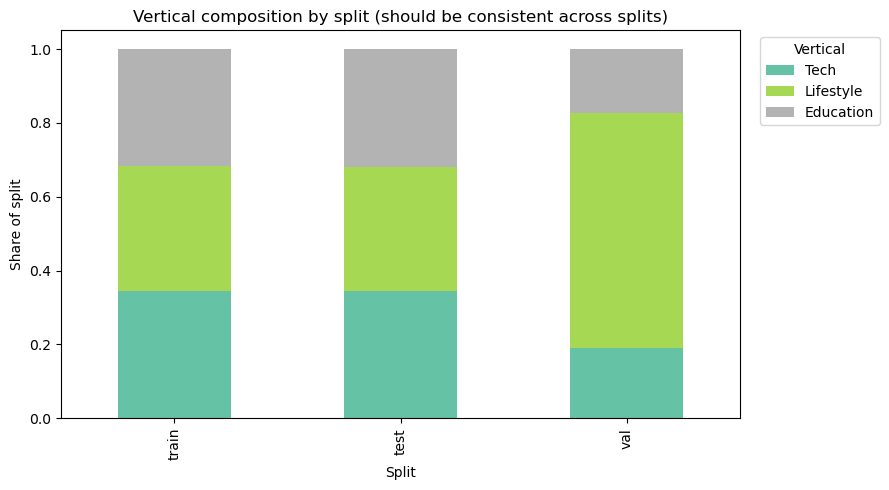

In [5]:
# Segment representation across splits (vertical x tier), merged back from df_clean.
labels = run.df_clean[["video_id", "vertical", "tier"]]
seg_frames = []
for name, dfs in [("train", run.df_train), ("test", run.df_test), ("val", run.df_val)]:
    merged = dfs[["video_id"]].merge(labels, on="video_id", how="left")
    share = merged["vertical"].value_counts(normalize=True).rename(name)
    seg_frames.append(share)
df_vertical_mix = pd.concat(seg_frames, axis=1).round(3)
print("Vertical share by split:")
print(df_vertical_mix.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
df_vertical_mix.T.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Vertical composition by split (should be consistent across splits)")
ax.set_ylabel("Share of split")
ax.set_xlabel("Split")
ax.legend(title="Vertical", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
split_fig = fig_path("03_split_vertical_mix.png")
if split_fig:
    plt.savefig(split_fig)
plt.show()

## Train all models

`ModelTrainer` trains Logistic Regression (L1), Random Forest, XGBoost, LightGBM,
MLP, and the soft-voting RF+XGB ensemble using the hyperparameters from the
current GCS snapshot, then evaluates each on the **test** split. Hyperparameter
search is *not* run here — that is the job of notebook 04. Cross-validation
underlies the tuned parameters loaded from the hyperparameter snapshot.

In [6]:
stages.trainer.run(run)
print(f"Total training time: {run.train_elapsed_s:.1f}s")
run.summary()

Loaded hyperparams 'v1.1' (saved 2026-04-29)
  Models: ['LogisticRegression', 'RandomForest', 'XGBoost', 'VotingClassifier']
  Search: {'strategy': 'random', 'n_iter': 100, 'cv': 5, 'scoring': 'roc_auc'}
Loaded hyperparams from snapshot 'v1.1'.
  Note: injected l1_ratio=0.5 for elasticnet LR (missing from snapshot).
  Note: 'LightGBM' not in snapshot — using defaults.
  Note: 'MLP' not in snapshot — using defaults.
Training LogisticRegression (L1)...
Training RandomForestClassifier...
Training XGBClassifier...
Training LGBMClassifier...
Training MLPClassifier...
Training VotingClassifier ensemble (RF + XGB, soft vote, weights=[1, 2])...
Training StackingClassifier (RF + XGB + LGB → LR, 5-fold CV)...

=== ModelTrainer — test-set results ===
  lr_l1               AUC=0.7792  acc=0.7129  F1↑=0.7479
  rf                  AUC=0.8922  acc=0.8122  F1↑=0.8384
  xgb                 AUC=0.9271  acc=0.8497  F1↑=0.8662
  lgb                 AUC=0.9213  acc=0.8424  F1↑=0.8597
  mlp                 

### (Optional) persist artifacts

In the persisting modes, snapshot the engineered splits and the trained models to
GCS. `FinalSnapshotter` writes only in `NEW_DATA` (engineered splits change with
new data); `ModelSnapshotter` writes in both `NEW_MODEL_OLD_DATA` and `NEW_DATA`.
Both are no-ops in `OLD_MODEL_OLD_DATA`.

In [7]:
stages.final_snapshotter.run(run)
stages.model_snapshotter.run(run)

[dry_run] FinalSnapshotter — GCS write skipped.
[dry_run] ModelSnapshotter — GCS write skipped.


PipelineRun(model_version='v6.1', num_synth_rows=0, populated=['df_videos', 'df_baselines', 'df_medians', 'df_clean', 'df_engineered', 'df_train', 'df_test', 'df_val', 'df_gen', 'X_train', 'X_test', 'X_val', 'X_val_unscaled', 'X_gen', 'y_train', 'y_test', 'y_val', 'y_gen', 'models'])

## Evaluate on the locked validation holdout

`Validator` scores each model on the locked holdout using each model's own saved
scaler, then `ValidationResultsSnapshotter` appends the run to the JSONL history
(skipped in `OLD_MODEL_OLD_DATA`; written in the persisting modes).

In [8]:
stages.validator.run(run)
stages.validation_results_snapshotter.run(run)


=== Validator — validation-set results ===
  lr_l1           AUC=0.7679  acc=0.7036  F1↑=0.7384
  rf              AUC=0.8861  acc=0.8062  F1↑=0.8332
  xgb             AUC=0.9220  acc=0.8415  F1↑=0.8586
  lgb             AUC=0.9182  acc=0.8380  F1↑=0.8565
  mlp             AUC=0.8545  acc=0.7666  F1↑=0.7853
  ensemble_voting  AUC=0.9188  acc=0.8421  F1↑=0.8598
  ensemble_stacking  AUC=0.9214  acc=0.8465  F1↑=0.8633
[dry_run] ValidationResultsSnapshotter — GCS append skipped.


PipelineRun(model_version='v6.1', num_synth_rows=0, populated=['df_videos', 'df_baselines', 'df_medians', 'df_clean', 'df_engineered', 'df_train', 'df_test', 'df_val', 'df_gen', 'X_train', 'X_test', 'X_val', 'X_val_unscaled', 'X_gen', 'y_train', 'y_test', 'y_val', 'y_gen', 'models', 'results'])

### A note on the evaluation metrics

Every metrics table in this notebook leads with three **global** scores —
`precision_macro`, `recall_macro`, `f1_macro` — followed by the per-class
breakdown (`*_above`, `*_below`).

The global scores use **sklearn's `average="macro"`**: compute precision /
recall / F1 separately for each class, then take the unweighted mean across
classes. For example, `f1_macro = mean(f1_above, f1_below)`. Because the
target is ~50/50 by design, macro and weighted averages are nearly identical
here — macro is preferred because it treats both classes equally regardless
of exact counts, which matches the intent of a balanced binary target.

The per-class split is retained because the error costs differ — a false
"will overperform" prediction has a different business impact than a false
"will underperform" — but the macro scores are shown first as the headline
numbers.

### Evaluation metric — choice & rationale

The **primary metric is ROC-AUC**: it measures how well a model ranks
above-baseline videos above below-baseline ones across *all* thresholds, which
matches the use case (flagging likely under/over-performers early, where the
decision threshold may be tuned later). Because the classes are ~balanced,
**accuracy** is also meaningful, and **macro F1** gives a single
threshold-dependent summary. ROC-AUC is the metric we select models on.

In [9]:
df_val = pd.DataFrame(run.results).T[METRIC_COLS].astype(float).round(4)
df_val.index.name = "model"
df_val.style.highlight_max(color="#d4edda").format("{:.4f}")

,roc_auc,accuracy,precision_macro,recall_macro,f1_macro,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
model,,,,,,,,,,,
lr_l1,0.7679,0.7036,0.6998,0.6974,0.6982,0.7242,0.7531,0.7384,0.6753,0.6417,0.6581
rf,0.8861,0.8062,0.8083,0.7982,0.8011,0.7985,0.8710,0.8332,0.8182,0.7253,0.7689
xgb,0.9220,0.8415,0.8400,0.8384,0.8391,0.8511,0.8662,0.8586,0.8290,0.8107,0.8197
lgb,0.9182,0.8380,0.8371,0.8340,0.8353,0.8434,0.8700,0.8565,0.8309,0.7981,0.8141
mlp,0.8545,0.7666,0.7641,0.7663,0.7648,0.8027,0.7687,0.7853,0.7255,0.7639,0.7442
ensemble_voting,0.9188,0.8421,0.8411,0.8383,0.8395,0.8479,0.8721,0.8598,0.8342,0.8046,0.8191
ensemble_stacking,0.9214,0.8465,0.8453,0.8432,0.8441,0.8541,0.8727,0.8633,0.8365,0.8137,0.8250


## Train vs. test vs. validation

To diagnose overfitting we score every model on the **training** split too, then
compare train / test / validation side by side. A large train→validation gap
means the model is memorizing the training data; a small gap with high
validation AUC is what we want.

The plot below shows ROC-AUC per model with the train−validation gap annotated
above each group (the chosen format: a single AUC-focused grouped bar with gap
labels). The full multi-metric table follows.

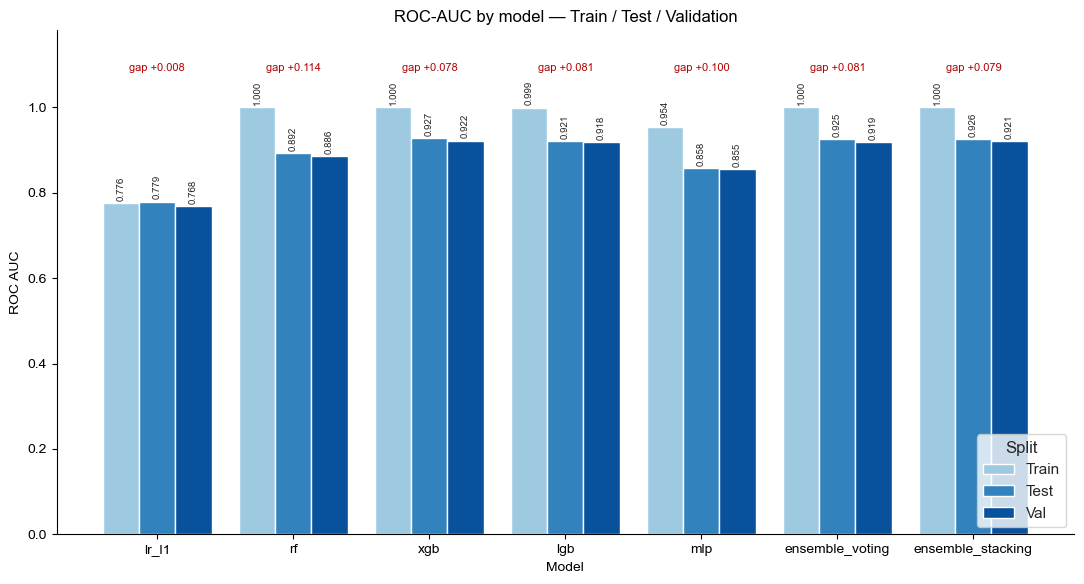

In [10]:
# Score every trained model on the train / test / validation splits.
train_results = {
    name: asdict(ModelResult.from_sklearn(
        entry["model"], run.X_train, run.y_train, run.X_train.columns.tolist()))
    for name, entry in run.models.items()
}
test_results = {name: asdict(entry["result"]) for name, entry in run.models.items()}
val_results = run.results

results_by_split = {"train": train_results, "test": test_results, "val": val_results}

eda.plot_split_comparison(
    results_by_split,
    metric="roc_auc",
    title="ROC-AUC by model — Train / Test / Validation",
    save_figure_name=fig_path("03_train_test_val_auc.png"),
)

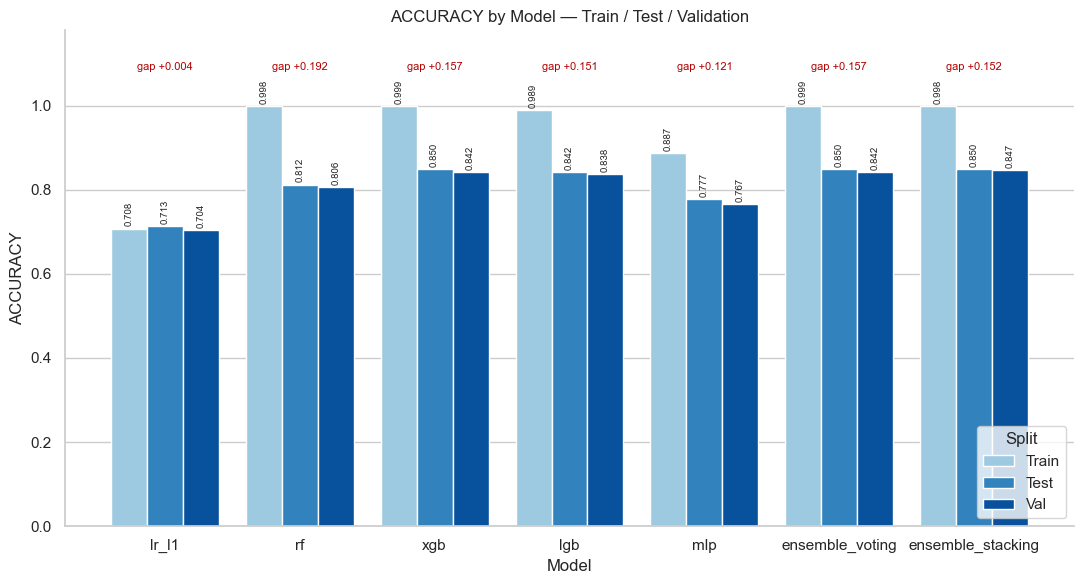

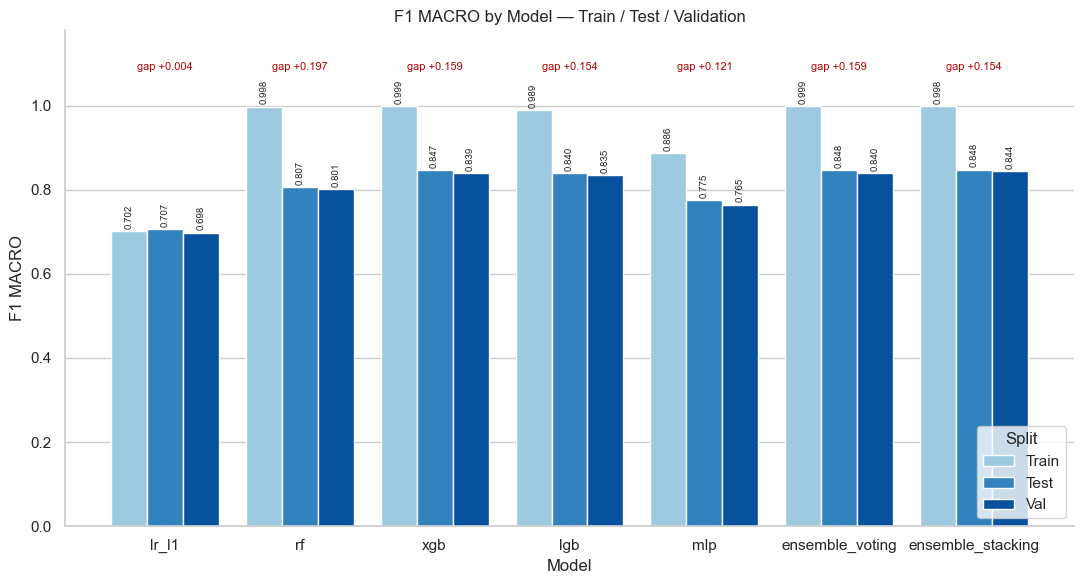

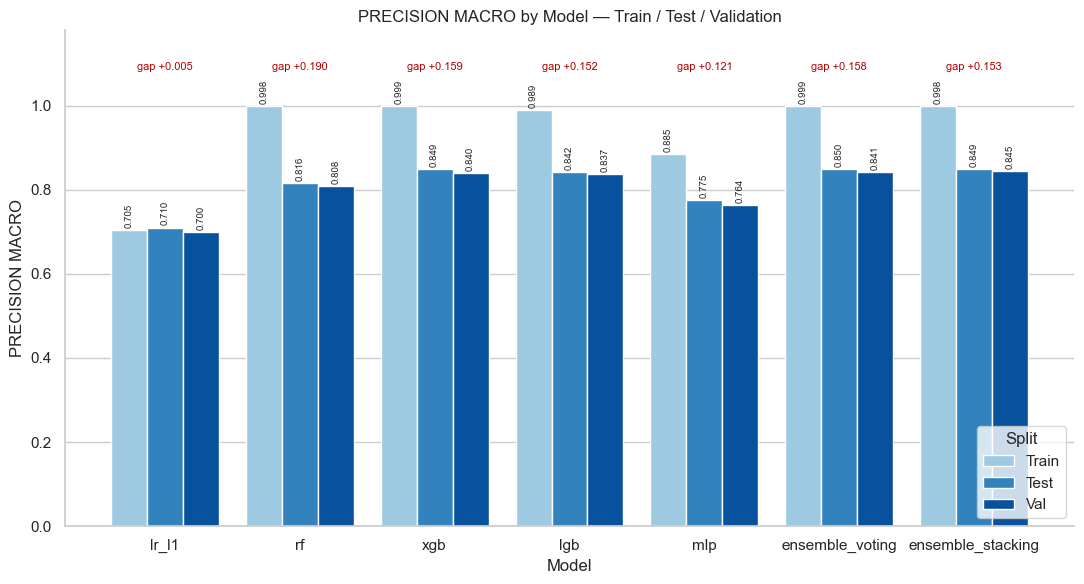

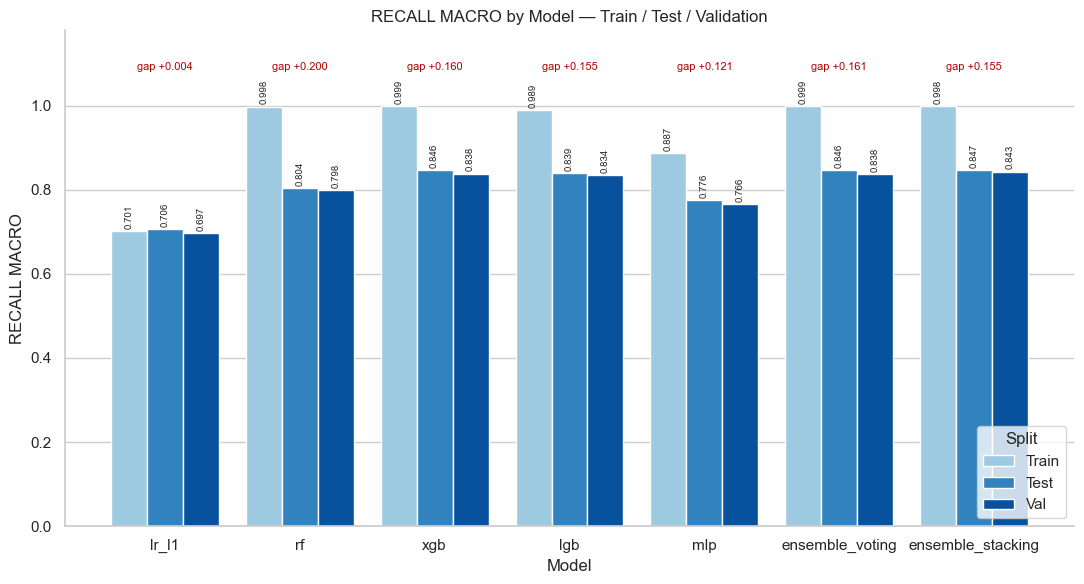

In [11]:
# Accuracy, macro F1, macro Precision, macro Recall — same split view.
for metric, fname in [
    ("accuracy",        "03_train_test_val_accuracy.png"),
    ("f1_macro",        "03_train_test_val_f1.png"),
    ("precision_macro", "03_train_test_val_precision.png"),
    ("recall_macro",    "03_train_test_val_recall.png"),
]:
    eda.plot_split_comparison(
        results_by_split,
        metric=metric,
        save_figure_name=fig_path(fname),
    )

In [12]:
# Full 3-way table (global macro metrics first, then per-class).
records = {}
for name in run.models:
    records[(name, "train")] = {m: train_results[name].get(m) for m in METRIC_COLS}
    records[(name, "test")] = {m: test_results[name].get(m) for m in METRIC_COLS}
    records[(name, "val")] = {m: val_results[name].get(m) for m in METRIC_COLS}

df_3way = pd.DataFrame(records).T.astype(float).round(4)
df_3way.index.names = ["model", "split"]
df_3way

roc_auc  accuracy  precision_macro  recall_macro  \
model             split                                                     
lr_l1             train   0.7757    0.7077           0.7045        0.7012   
                  test    0.7792    0.7129           0.7100        0.7062   
                  val     0.7679    0.7036           0.6998        0.6974   
rf                train   1.0000    0.9980           0.9980        0.9979   
                  test    0.8922    0.8122           0.8156        0.8040   
                  val     0.8861    0.8062           0.8083        0.7982   
xgb               train   1.0000    0.9985           0.9986        0.9985   
                  test    0.9271    0.8497           0.8491        0.8462   
                  val     0.9220    0.8415           0.8400        0.8384   
lgb               train   0.9994    0.9893           0.9891        0.9892   
                  test    0.9213    0.8424           0.8416        0.8388   
                  val     0.9182    0.8380           0.8371        0.8340   
mlp               train   0.9543    0.8873           0.8855        0.8875   
                  test    0.8579    0.7775           0.7749        0.7763   
                  val     0.8545    0.7666           0.7641        0.7663   
ensemble_voting   train   1.0000    0.9989           0.9989        0.9989   
                  test    0.9248    0.8501           0.8501        0.8460   
                  val     0.9188    0.8421           0.8411        0.8383   
ensemble_stacking train   1.0000    0.9981           0.9980        0.9981   
                  test    0.9264    0.8501           0.8493        0.8469   
                  val     0.9214    0.8465           0.8453        0.8432   

                         f1_macro  precision_above  recall_above  f1_above  \
model             split                                                      
lr_l1             train    0.7022           0.7241        0.7621    0.7426   
                  test     0.7073           0.7273        0.7697    0.7479   
                  val      0.6982           0.7242        0.7531    0.7384   
rf                train    0.9979           0.9979        0.9984    0.9982   
                  test     0.8071           0.7999        0.8808    0.8384   
                  val      0.8011           0.7985        0.8710    0.8332   
xgb               train    0.9985           0.9982        0.9991    0.9987   
                  test     0.8474           0.8535        0.8793    0.8662   
                  val      0.8391           0.8511        0.8662    0.8586   
lgb               train    0.9892           0.9910        0.9896    0.9903   
                  test     0.8400           0.8471        0.8727    0.8597   
                  val      0.8353           0.8434        0.8700    0.8565   
mlp               train    0.8863           0.9084        0.8856    0.8969   
                  test     0.7755           0.8059        0.7875    0.7966   
                  val      0.7648           0.8027        0.7687    0.7853   
ensemble_voting   train    0.9989           0.9990        0.9990    0.9990   
                  test     0.8476           0.8501        0.8852    0.8673   
                  val      0.8395           0.8479        0.8721    0.8598   
ensemble_stacking train    0.9980           0.9987        0.9978    0.9982   
                  test     0.8479           0.8554        0.8775    0.8663   
                  val      0.8441           0.8541        0.8727    0.8633   

                         precision_below  recall_below  f1_below  
model             split                                           
lr_l1             train           0.6848        0.6403    0.6618  
                  test            0.6926        0.6426    0.6667  
                  val             0.6753        0.6417    0.6581  
rf                train           0.9981        0.9974    0.9977  
                  test            0.8312        0.7271  

## Segment audit

A single global model can hide blind spots: it may rank well overall yet
underperform on a specific vertical or channel tier. `SegmentAuditor` evaluates
each model on per-vertical and per-tier slices of the validation set and flags
segments whose ROC-AUC drops materially below the global figure. This directly
informs final model selection (notebook 05) and whether segment-specific models
are worth exploring.

In [13]:
# df_val retains the vertical/tier string columns; merge them back defensively
# in case a future engineering change drops them.
df_val_seg = run.df_val
if "vertical" not in df_val_seg.columns or "tier" not in df_val_seg.columns:
    df_val_seg = df_val_seg.merge(
        run.df_clean[["video_id", "vertical", "tier"]], on="video_id", how="left"
    )

auditor = SegmentAuditor(
    models=run.models,
    X_val=run.X_val,      # scaled with this run's scaler — matches freshly trained models
    y_val=run.y_val,
    df_val=df_val_seg,
    threshold=0.5,        # default operating threshold; a sweep is future work
)
segment_results = auditor.audit()
auditor.print_summary(segment_results)


  Segment audit — VERTICAL
vertical      ensemble_stacking  auc    ensemble_voting  auc    lgb  auc    lr_l1  auc    mlp  auc    rf  auc    xgb  auc    ensemble_stacking  acc    ensemble_voting  acc    lgb  acc    lr_l1  acc    mlp  acc    rf  acc    xgb  acc
----------  ------------------------  ----------------------  ----------  ------------  ----------  ---------  ----------  ------------------------  ----------------------  ----------  ------------  ----------  ---------  ----------
Education                     0.9147                  0.9120      0.9125        0.7735      0.8638     0.8883      0.9146                    0.8363                  0.8351      0.8326        0.7144      0.7778     0.8021      0.8332
Lifestyle                     0.9417                  0.9393      0.9384        0.7730      0.8611     0.9035      0.9432                    0.8721                  0.8700      0.8602        0.7062      0.7612     0.8303      0.8711
Tech                          0.9047    

## Feature importance

What is each model relying on? For the tree models this is impurity-reduction
importance; for Logistic Regression it is the (signed) coefficient. The patterns
here corroborate the project thesis that *channel-relative, contextual* signals
(normalized rates, baseline comparisons, tier, content format) outrank absolute
counts.

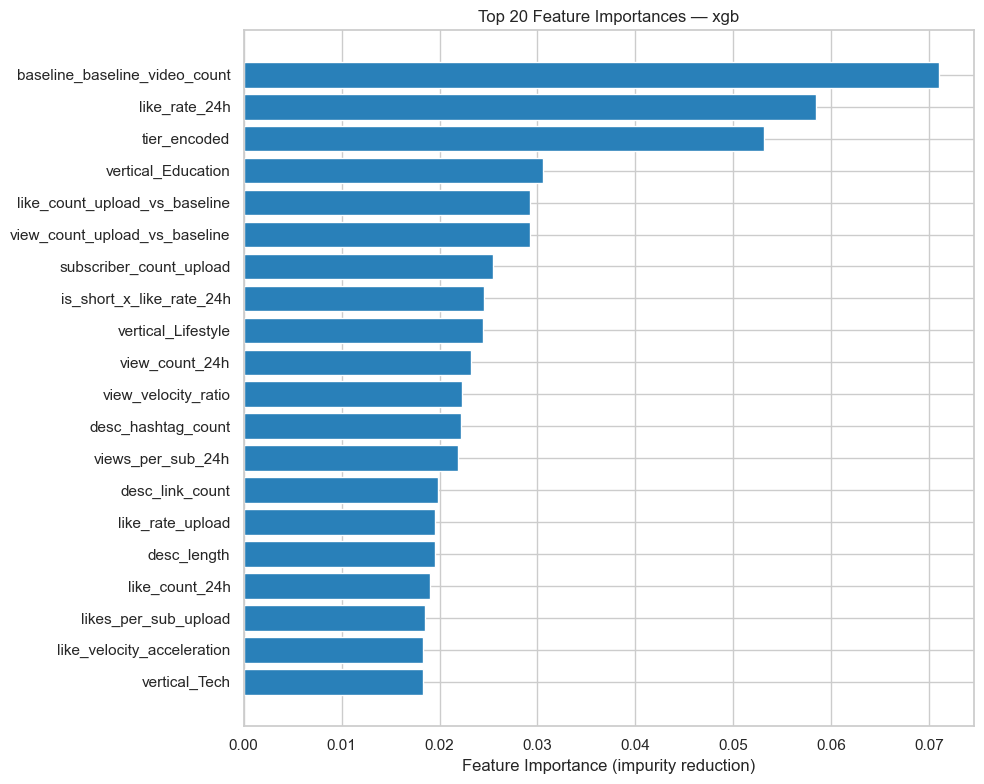

Model 'ensemble_stacking' does not expose feature importances.
Model 'ensemble_voting' does not expose feature importances.
lr_l1:
  like_count_upload_vs_baseline        +11.1883
  view_count_upload_vs_baseline        -2.8818
  like_rate_24h                        +1.1284
  view_count_velocity_24h              -0.8148
  like_velocity_upload                 -0.6028
rf:
  like_rate_24h                        +0.1044
  view_velocity_ratio                  +0.0452
  like_count_upload_vs_baseline        +0.0388
  like_rate_upload                     +0.0364
  duration_seconds                     +0.0304
xgb:
  baseline_baseline_video_count        +0.0710
  like_rate_24h                        +0.0585
  tier_encoded                         +0.0531
  vertical_Education                   +0.0306
  like_count_upload_vs_baseline        +0.0293
lgb:
  like_count_upload_vs_baseline        +1144.0000
  view_count_upload_vs_baseline        +1013.0000
  like_rate_24h                        +943.0000


In [14]:
# Top 3 models by test-set AUC — plot feature importance for each.
top3 = sorted(
    run.models.items(),
    key=lambda kv: kv[1]["result"].roc_auc,
    reverse=True,
)[:3]

for model_name, _ in top3:
    eda.plot_feature_importance(
        run,
        model_name=model_name,
        top_n=20,
        save_figure_name=fig_path(f"03_feature_importance_{model_name}.png"),
    )

for name, entry in run.results.items():
    top = entry.get("top_features", [])[:5]
    print(f"{name}:")
    for f in top:
        key = "coefficient" if "coefficient" in f else "importance"
        print(f"  {f['feature']:35s}  {f[key]:+.4f}")

## Cross-version context

Where does this run sit in the project's history? The trajectory plots below load
every saved model snapshot from GCS and chart metric progression across model
generations. The dashed vertical line marks the methodology change at v4.0, when
a locked holdout replaced per-run test sets — comparisons across that line are
directional, not apples-to-apples. (These plots also appear, focused on the
final model, in notebook 05.)

In [15]:
eda.load_model_comparison(run)

Loaded 44 model snapshots


,model_type,data_snapshot,training_date,real_rows,synth_rows,accuracy,roc_auc,precision_macro,recall_macro,f1_macro,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
version,,,,,,,,,,,,,,,,
v1.0_lr_l1,LogisticRegression,v1.0_model_mixed66,2026-03-26,2100,5000,0.6305,0.6258,0.6258,0.6036,0.5981,0.6366,0.8081,0.7122,0.6149,0.3991,0.4840
v1.0_rf,RandomForest,v1.0_model_mixed66,2026-03-26,2100,5000,0.6952,0.7595,0.6898,0.6848,0.6862,0.7161,0.7643,0.7394,0.6635,0.6053,0.6330
v1.0_xgb,XGBoost,v1.0_model_mixed66,2026-03-26,2100,5000,0.7105,0.7703,0.7066,0.7089,0.7072,0.7562,0.7205,0.7379,0.6570,0.6974,0.6766
v2.0_lr_l1,LogisticRegression,v2.0_mixed_70real,2026-03-26,3255,1743,0.6229,0.6464,0.6153,0.6017,0.5988,0.6360,0.7707,0.6969,0.5946,0.4326,0.5008
v2.0_rf,RandomForest,v2.0_mixed_70real,2026-03-26,3255,1743,0.7334,0.7966,0.7339,0.7197,0.7223,0.7322,0.8297,0.7779,0.7356,0.6096,0.6667
v2.0_xgb,XGBoost,v2.0_mixed_70real,2026-03-26,3255,1743,0.7297,0.7971,0.7267,0.7198,0.7218,0.7409,0.7991,0.7689,0.7125,0.6404,0.6746
v3.0_lr_l1,LogisticRegression,v3.0_mixed_80real,2026-03-28,4037,1261,0.6406,0.6557,0.6399,0.6169,0.6123,0.6416,0.8127,0.7171,0.6382,0.4212,0.5075
v3.0_rf,RandomForest,v3.0_mixed_80real,2026-03-28,4037,1261,0.7604,0.8246,0.7614,0.7491,0.7520,0.7571,0.8428,0.7977,0.7658,0.6554,0.7063
v3.0_xgb,XGBoost,v3.0_mixed_80real,2026-03-28,4037,1261,0.7624,0.8303,0.7592,0.7567,0.7577,0.7791,0.8039,0.7913,0.7394,0.7095,0.7241


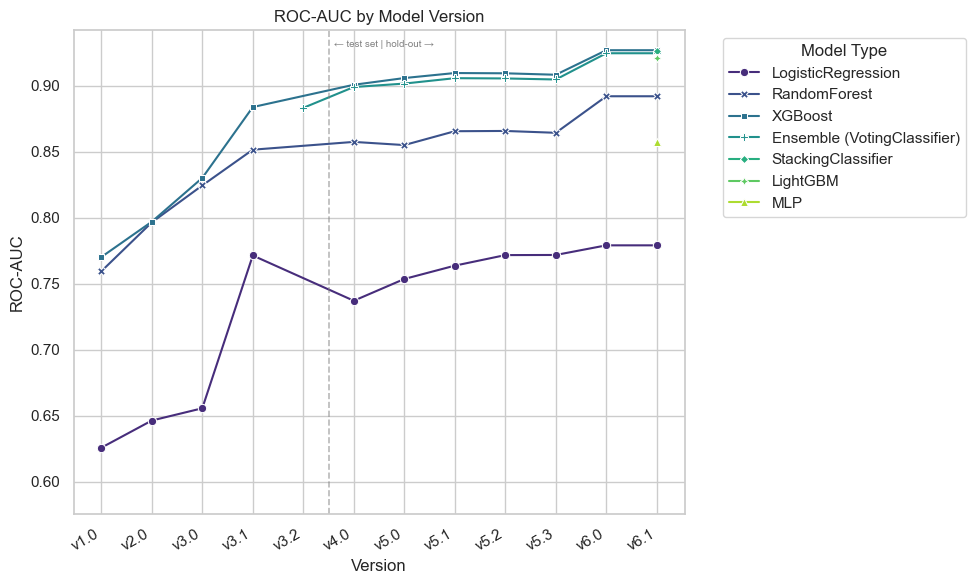

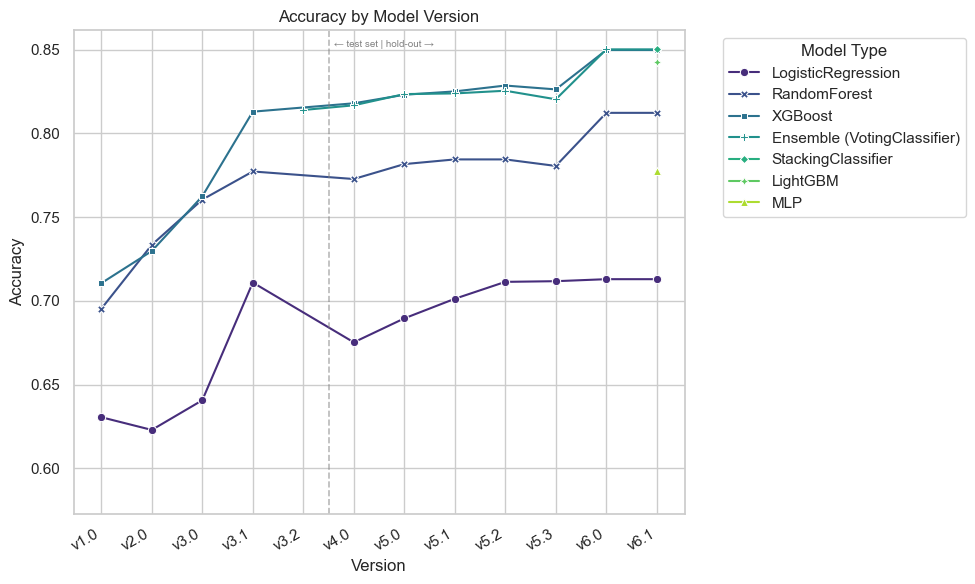

In [16]:
eda.plot_roc_auc(run, save_figure_name=fig_path("roc_auc_by_version_line.png"))
eda.plot_accuracy(run, save_figure_name=fig_path("accuracy_by_model.png"))

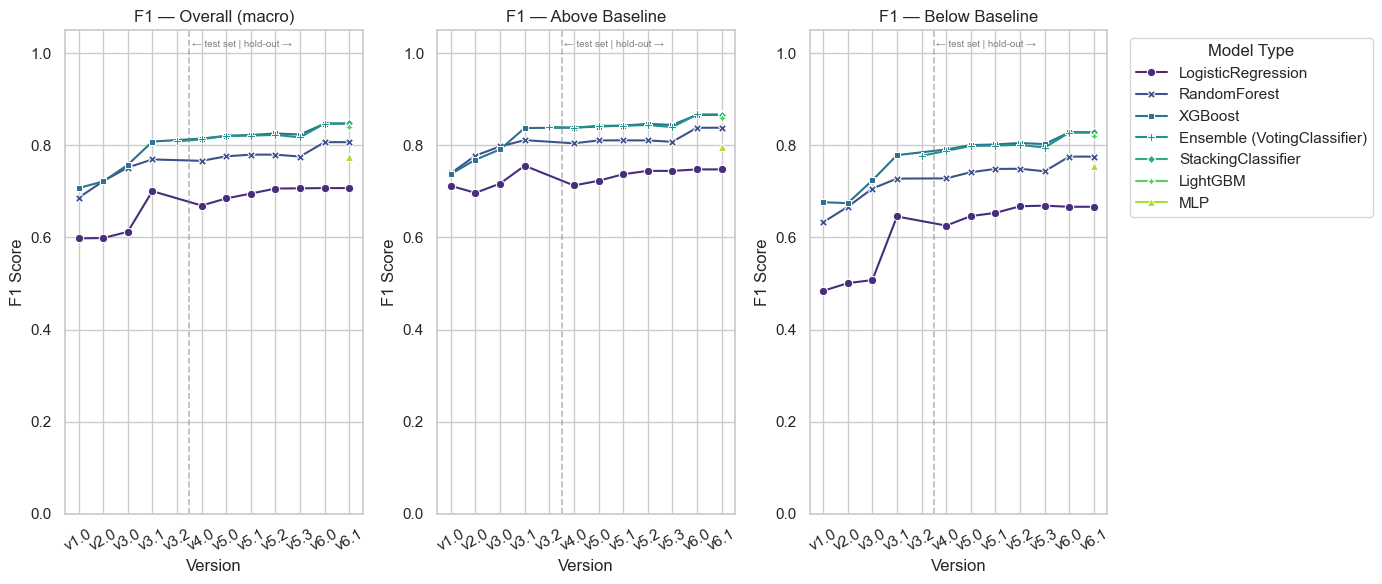

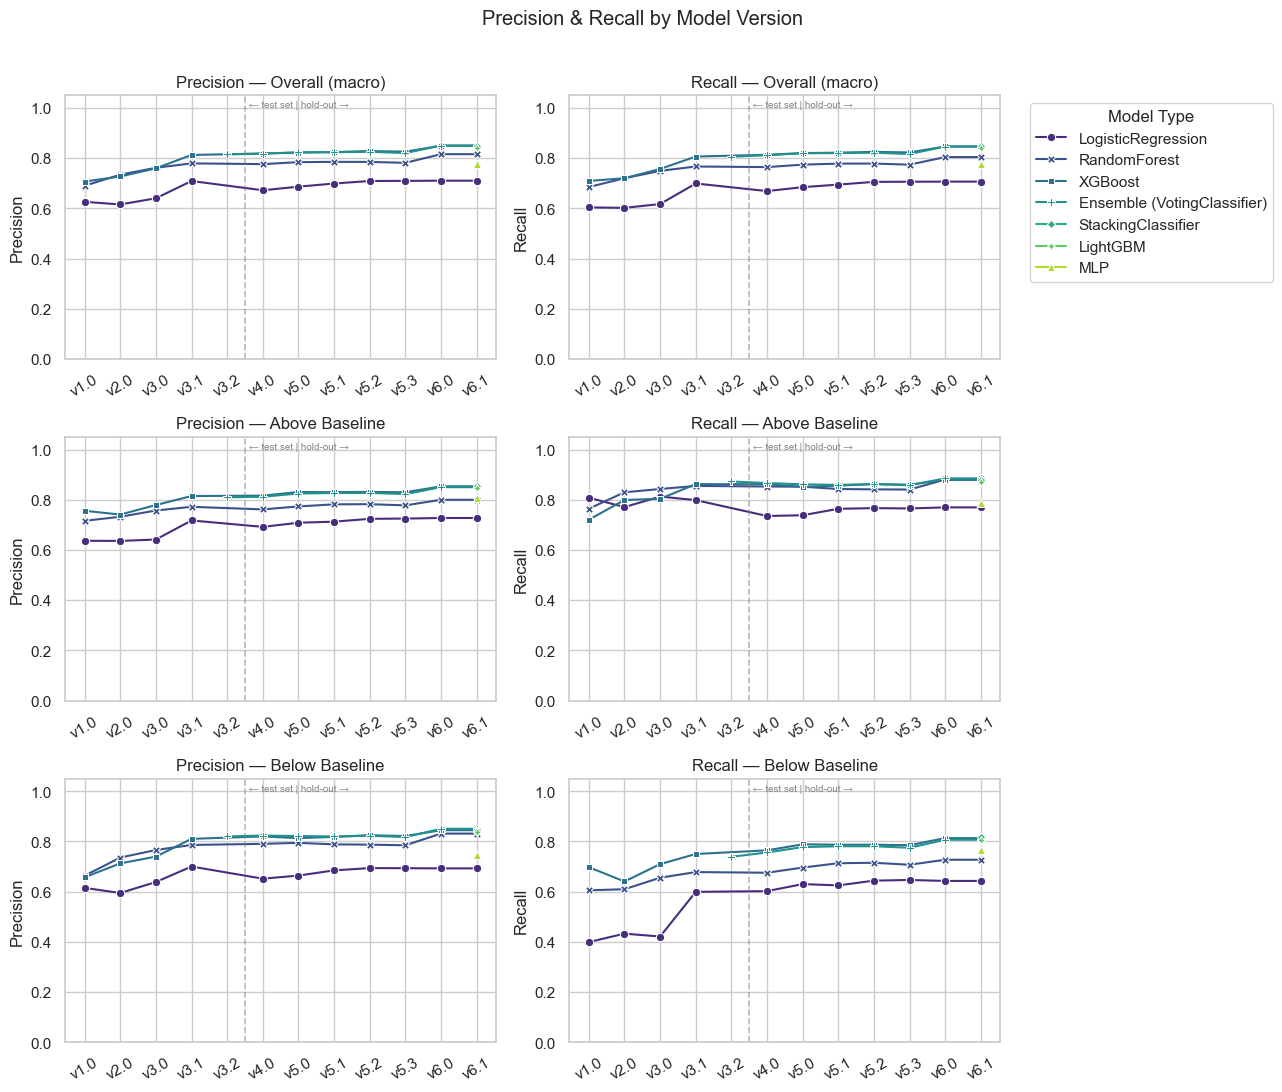

In [17]:
# F1 and precision/recall now lead with the global (macro) panel, then per-class.
eda.plot_f1(run, save_figure_name=fig_path("f1_by_model.png"))
eda.plot_precision_recall(run, save_figure_name=fig_path("precision_recall_by_model.png"))

Loaded 44 model snapshots


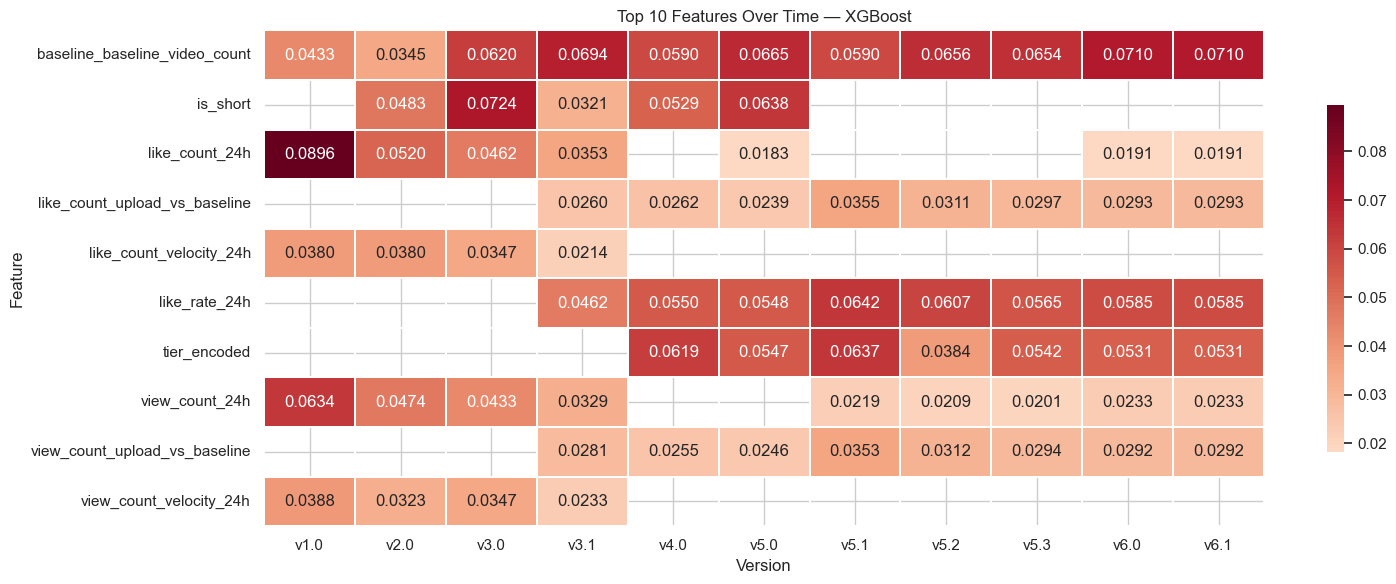

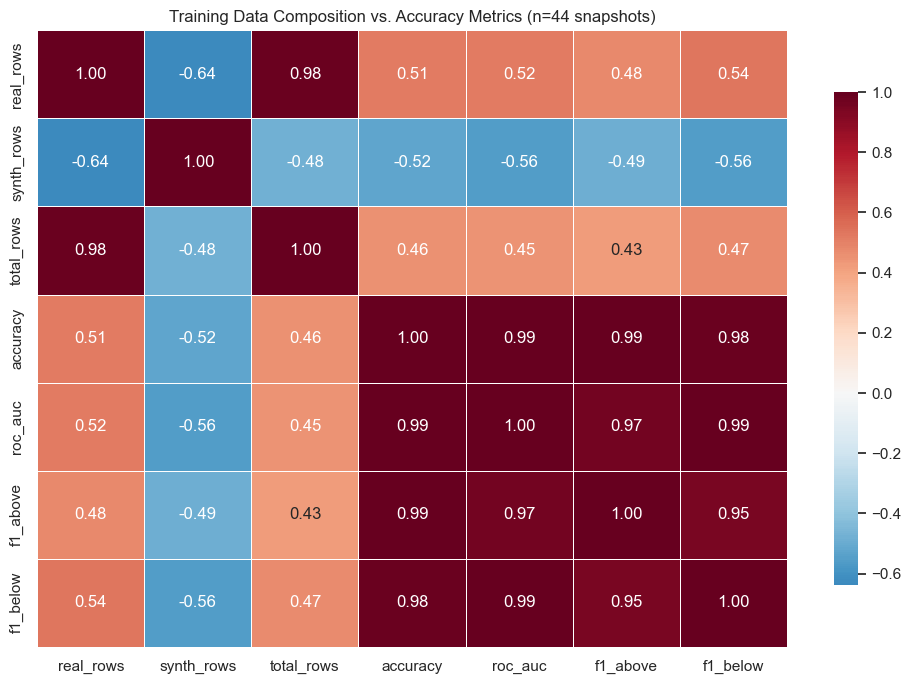

In [18]:
eda.plot_top_features_over_time(run, ModelType.XGB, save_figure_name=fig_path("features_over_time_xgb.png"))
eda.plot_data_composition_vs_accuracy(run, save_figure_name=fig_path("data_composition_accuracy.png"))

## Findings & next steps

<TODO(jelani): Add findings. Touch on below topics>

- **Model ranking** 
  - The persistent ~non-linear gap between the tree models and Logistic Regression
  - The core modeling finding of the project.
  - **segment blind spots** the audit surfaced (a vertical or tier where the
  leading model degrades), which feeds the final-selection decision.

---

### v6.0 results (data snapshot v3.5_100real — 19,589 train rows)

| model | ROC-AUC | accuracy | f1_macro | f1_above | f1_below |
|-------|---------|----------|----------|----------|---------|
| XGBoost | **0.9271** | 0.8497 | 0.8474 | 0.8662 | 0.8286 |
| Ensemble (RF+XGB 1:2) | 0.9248 | **0.8501** | **0.8476** | **0.8673** | 0.8279 |
| Random Forest | 0.8922 | 0.8122 | 0.8071 | 0.8384 | 0.7757 |
| Logistic Regression | 0.7792 | 0.7129 | 0.7073 | 0.7479 | 0.6667 |

#### Model ranking

XGBoost leads on ROC-AUC (0.9271) and the ensemble is essentially tied (0.9248, Δ=0.0023). The AUC difference is within run-to-run noise and the ensemble has a marginal edge on accuracy and macro F1. RF trails by ~3.5 AUC points — meaningfully worse but still a strong single-model option. LR sits at 0.7792, consistent with its 0.76–0.78 ceiling across every prior version.

#### The non-linear gap is structural

The LR → XGB AUC gap is ~0.148. The feature set is dominated by non-linear signals — velocity ratios, subscriber-normalized engagement rates, tier interactions, and the `is_short × like_rate_24h` cross — that a linear decision boundary cannot fully exploit. The gap has been stable across v1.0 through v6.0 and is unlikely to close with tuning. LR is useful as a fast interpretable baseline, not a deployment candidate.

#### XGB vs. ensemble

XGB edges out on AUC (0.9271 vs 0.9248), while the ensemble is slightly ahead on accuracy (0.8501 vs 0.8497) and f1_above (0.8673 vs 0.8662). The RF component (weight=1) adds marginal diversity but the XGB component (weight=2) dominates the ensemble vote — the two are effectively equivalent. Either is a viable final candidate; XGB is simpler to serve and inspect.

#### Segment blind spots (v5.3 audit — pattern expected to hold in v6.0)

- **Tier S** is the only consistent blind spot: tree models all drop ~0.04 AUC below their global score (XGB: 0.868 vs 0.909 global; RF: 0.831 vs 0.872). Small channels have lower baseline video counts and noisier engagement rates, so the normalized signals are less stable.
- **Vertical** shows no blind spots — Education, Lifestyle, and Tech all stay within 0.02 AUC of the global score. The model generalizes across content categories within the current three-vertical scope.

#### Top features

`like_rate_24h` is the single strongest predictor in both XGB and RF, confirming that likes-per-hour at 24 h is the most reliable early momentum signal. The next tier — `baseline_baseline_video_count`, `tier_encoded`, baseline-normalized view/like ratios, and `view_velocity_ratio` — reflects channel scale and context-relative performance rather than raw counts. `tier_encoded` ranking 3rd in XGB confirms that the channel scale effect is real and captured. Thumbnail features (`brightness`, `colorfulness`) appear in RF's top 20 with modest importance, suggesting mild but nonzero signal.

#### Next steps

- **Hyperparameter tuning (notebook 04):** XGB and RF are the tuning targets. LR improvements are capped; the ensemble inherits RF/XGB params so it benefits automatically.
- **Tier S gap:** the ~0.04 AUC drop for small channels is the most actionable blind spot. Options worth exploring: a lower classification threshold for S-tier predictions, or a dedicated S-tier sub-model trained on the S segment only.

**Next:** [04 · Hyperparameter tuning](./04_hyperparameter_tuning.ipynb)

## Persist version bump (GCS)

Runs only in the persisting modes (`NEW_MODEL_OLD_DATA` or `NEW_DATA`); a no-op in
`OLD_MODEL_OLD_DATA`.

In [19]:
config.commit()

[dry_run] commit skipped — versions.json not written to GCS.


Exception ignored in: <function ResourceTracker.__del__ at 0x102915300>
Traceback (most recent call last):
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1029b1300>
Traceback (most recent call last):
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
Chi